# **EXPLORATORY DATA ANALYSIS**

This dataset contains unified, high-quality historical daily stock market data for 233 top US publicly traded companies selected from the S&P 500 index. It covers major industry sectors including Technology, Financials, Healthcare, Consumer Discretionary, Energy, and Industrials (featuring leaders like NVDA, AAPL, MSFT, AMZN, GOOGL, META, TSLA, JPM, WMT, XOM, and more).

In [1]:
# Loading packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

In [2]:
## Loading and Inspecting Data
data=pd.read_csv('master_stock_data.csv')
print((data.shape))
print(data.head())
print(data.tail())
print(data.sample(5, random_state=42))
print(data.columns)
print(data.dtypes)
print(data.info())

(2219678, 10)
         Date Ticker  Adj Close      Close  Dividends       High        Low  \
0  1999-11-18      A  26.189770  31.473534        0.0  35.765381  28.612303   
1  1999-11-19      A  24.032093  28.880545        0.0  30.758226  28.478184   
2  1999-11-22      A  26.189770  31.473534        0.0  31.473534  28.657009   
3  1999-11-23      A  23.808886  28.612303        0.0  31.205294  28.612303   
4  1999-11-24      A  24.441307  29.372318        0.0  29.998213  28.612303   

        Open  Stock Splits    Volume  
0  32.546494           0.0  62546380  
1  30.713518           0.0  15234146  
2  29.551144           0.0   6577870  
3  30.400572           0.0   5975611  
4  28.701717           0.0   4843231  
               Date Ticker  Adj Close      Close  Dividends       High  \
2219673  2026-08-24    ZTS  77.169998  77.169998        0.0  78.199997   
2219674  2026-08-25    ZTS  77.290001  77.290001        0.0  77.449997   
2219675  2026-08-26    ZTS  77.519997  77.519997       

## **Data Quality Checks**

In [3]:
## Missing value check
missing=data.isna().sum()
print(missing)
print(f'Number of missing values: {missing.sum()}')
###There are a total of 20 missing values in the dataset, which is a very small number compared to the total number of rows in the dataset. Therefore, we can drop these rows without losing much information.

## Duplicate value check
duplicates=data.duplicated().sum()
print(f'Number of duplicate rows: {duplicates}')
###There are no duplicate rows in the dataset.

## Unique value check
num_unique=data.nunique()
print(f'Number of unique values: \n {num_unique}')
###

## Numeric ranges
data.describe().T

Date            0
Ticker          0
Adj Close       4
Close           4
Dividends       0
High            4
Low             4
Open            4
Stock Splits    0
Volume          0
dtype: int64
Number of missing values: 20
Number of duplicate rows: 0
Number of unique values: 
 Date              16274
Ticker              233
Adj Close       1579999
Close            348675
Dividends          2369
High             340639
Low              338386
Open             332312
Stock Splits         99
Volume           641211
dtype: int64


,count,mean,std,min,25%,50%,75%,max
Adj Close,2219674.0,5.264464e+01,1.243302e+02,0.001390,3.695000,1.758173e+01,5.055696e+01,4.354540e+03
Close,2219674.0,6.233022e+01,1.317140e+02,0.005208,7.689815,2.750000e+01,6.505000e+01,4.354540e+03
Dividends,2219678.0,4.020821e-03,1.229074e-01,0.000000,0.000000,0.000000e+00,0.000000e+00,9.000000e+01
High,2219674.0,6.302458e+01,1.331598e+02,0.005208,7.791667,2.787000e+01,6.575751e+01,4.388110e+03
Low,2219674.0,6.160433e+01,1.301917e+02,0.004801,7.583333,2.714500e+01,6.431512e+01,4.316680e+03
Open,2219674.0,6.232195e+01,1.317019e+02,0.005208,7.687500,2.750000e+01,6.502973e+01,4.334810e+03
Stock Splits,2219678.0,8.558764e-04,6.963233e-02,0.000000,0.000000,0.000000e+00,0.000000e+00,5.000000e+01
Volume,2219678.0,1.088308e+07,5.624943e+07,0.000000,993400.000000,2.582729e+06,6.510700e+06,9.230856e+09


## **Univariate Analysis**

In [4]:
# Univariate Analysis
print(data.columns)

Index(['Date', 'Ticker', 'Adj Close', 'Close', 'Dividends', 'High', 'Low',
       'Open', 'Stock Splits', 'Volume'],
      dtype='str')


In [5]:
## Variable "Date"
print("Variable 'Date':")
print(data['Date'].describe())
print(data['Date'].max())
print(data['Date'].min())
print(data['Date'].value_counts())
print(data['Date'].value_counts().max())
print(data['Date'].value_counts().min())
print(data['Date'].value_counts().sample(5, random_state=42))
### Trading day date in YYYY-MM-DD format.
### Clearly, the dataset covers 16274 distinct trading days, from 1962-01-02 to 2026-08-31.
### Also, not all stocks are traded on all days. For example, on 1962-03-26, 18 stocks were traded, while on 2026-08-31, all 233 stocks were traded. This is expected, as some stocks may not have been listed or may have been delisted during the time period covered by the dataset.
print('\n')

Variable 'Date':
count        2219678
unique         16274
top       2026-07-17
freq             233
Name: Date, dtype: object
2026-08-31
1962-01-02
Date
2026-07-17    233
2026-08-04    233
2026-08-05    233
2026-08-06    233
2026-08-07    233
             ... 
1962-03-26     18
1962-03-27     18
1962-03-28     18
1962-03-29     18
1962-03-30     18
Name: count, Length: 16274, dtype: int64
233
18
Date
2023-01-18    231
1981-02-13     90
2004-04-16    186
2022-08-19    231
2014-01-28    219
Name: count, dtype: int64




In [6]:
##Variable "Ticker"
print("Variable 'Ticker':")
print(data['Ticker'].describe())
print(data['Ticker'].value_counts())
print(data['Ticker'].value_counts().max())
print(data['Ticker'].value_counts().min())
print(data['Ticker'].value_counts().sample(5, random_state=42))
### Stock ticker symbol identifying the company (e.g., NVDA, AAPL, MSFT).
### Clearly, there are 233 distinct stocks in the dataset, with the number of trading days for each stock varying from 6 (EA) to 16274 (CVX). This is expected, as some stocks may have been listed or delisted during the time period covered by the dataset.
print('\n')

Variable 'Ticker':
count     2219678
unique        233
top           CVX
freq        16274
Name: Ticker, dtype: object
Ticker
CVX     16274
AEP     16273
BA      16273
CAT     16273
DIS     16273
        ...  
OTIS     1620
PLTR     1486
CEG      1157
CICC      137
EA          6
Name: count, Length: 233, dtype: int64
16274
6
Ticker
TMO     11708
ZTS      3414
CICC      137
JNJ     16273
KEY      9776
Name: count, dtype: int64




Variable 'Adj Close':
count    2.219674e+06
mean     5.264464e+01
std      1.243302e+02
min      1.389660e-03
25%      3.695000e+00
50%      1.758173e+01
75%      5.055696e+01
max      4.354540e+03
Name: Adj Close, dtype: float64
Skewness: 10.66064299316465
Kurtosis: 213.94206823585023
Maximum: 4354.5400390625, Minimum: 0.001389660174027


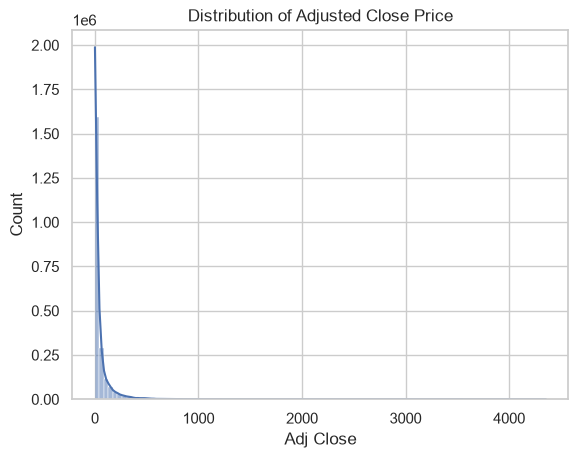

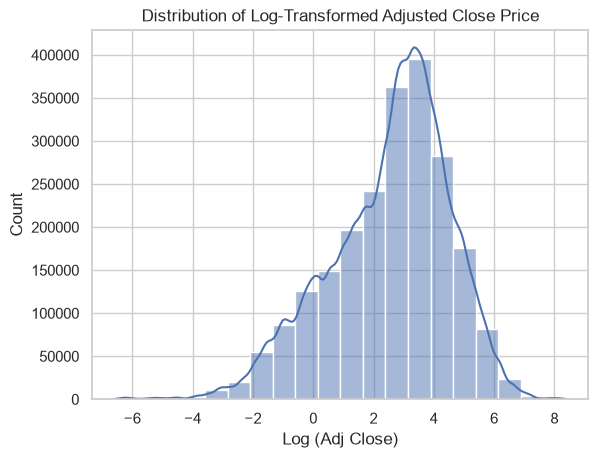

In [7]:
## Variable "Adj Close"
print("Variable 'Adj Close':")
print(data['Adj Close'].describe()) 
print(f"Skewness: {data['Adj Close'].skew()}")
print(f"Kurtosis: {data['Adj Close'].kurtosis()}")
print(f"Maximum: {data['Adj Close'].max()}, Minimum: {data['Adj Close'].min()}")
sns.histplot(data['Adj Close'], bins=100, kde=True)
plt.xlabel('Adj Close')
plt.title('Distribution of Adjusted Close Price')
plt.show()
### Adjusted closing price accounting for stock splits and dividend distributions (USD).
### Clearly, the data is heavily right-skewed, with a skewness of ~10.66 and a kurtosis of 213.94. The minimum adjusted closing price is ~0.01 USD, while the maximum is ~4354.54 USD. The median adjusted closing price is ~17.58 USD, while the mean is ~52.64 USD. This indicates that there are some very high adjusted closing prices that are pulling the mean up.
### We log transform the adjusted closing price to reduce the skewness and kurtosis, and to make the distribution more normal.
log_adj_close = np.log(data['Adj Close'].dropna())
sns.histplot(log_adj_close, bins=20, kde=True)
plt.xlabel('Log (Adj Close)')
plt.title('Distribution of Log-Transformed Adjusted Close Price')
plt.show()

Variable 'Close':
count    2.219674e+06
mean     6.233022e+01
std      1.317140e+02
min      5.208000e-03
25%      7.689815e+00
50%      2.750000e+01
75%      6.505000e+01
max      4.354540e+03
Name: Close, dtype: float64
Skewness: 9.873375079940354
Kurtosis: 178.05226564985597
Maximum: 4354.5400390625, Minimum: 0.005208000075072


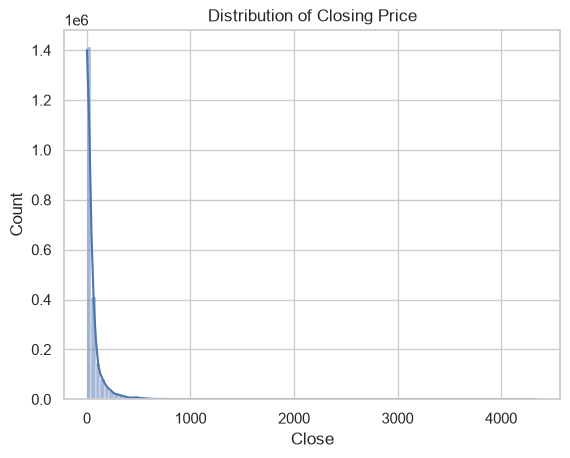

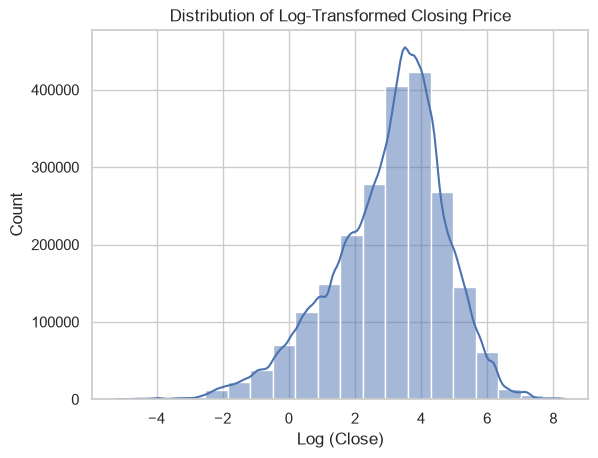

In [8]:
## Variable "Close"
print("Variable 'Close':")
print(data['Close'].describe())
print(f"Skewness: {data['Close'].skew()}")
print(f"Kurtosis: {data['Close'].kurtosis()}")
print(f"Maximum: {data['Close'].max()}, Minimum: {data['Close'].min()}")
sns.histplot(data['Close'], bins=100, kde=True)
plt.xlabel('Close')
plt.title('Distribution of Closing Price')
plt.show()
### Unadjusted closing stock price (USD).
### Clearly, this data is also heavily right-skewed, with a skewness of ~9.87 and kurtosis of ~178.05. The minimum close price is ~0.0052 USD, while the maximum close price is ~4354.54 USD. The median close price is ~27.50 USD, while the mean is ~62.33 USD. This indicates that there are some very high close prices that are pulling the mean up.
### Again, we log transform the adjusted closing price to reduce the skewness and kurtosis, and to make the distribution more normal.
log_close = np.log(data['Close'].dropna())
sns.histplot(log_close, bins=20, kde=True)
plt.xlabel('Log (Close)')
plt.title('Distribution of Log-Transformed Closing Price')
plt.show()

Variable 'Dividends':
count    2.219678e+06
mean     4.020821e-03
std      1.229074e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      9.000000e+01
Name: Dividends, dtype: float64
Skewness: 371.11310462859836
Kurtosis: 217486.1548496438
Maximum: 90.0, Minimum: 0.0
Proportion of zero dividends: 0.9882901934424723


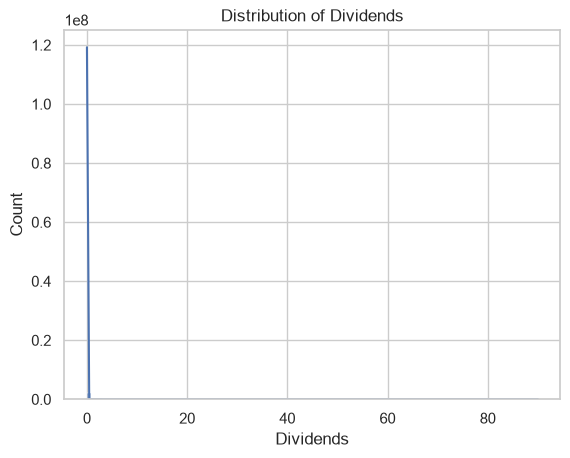

In [9]:
## Variable "Dividends"
print("Variable 'Dividends':")
print(data['Dividends'].describe())
print(f"Skewness: {data['Dividends'].skew()}")
print(f"Kurtosis: {data['Dividends'].kurtosis()}")
print(f"Maximum: {data['Dividends'].max()}, Minimum: {data['Dividends'].min()}")
print(f"Proportion of zero dividends: {data['Dividends'].value_counts()[0] / len(data['Dividends'])}")
sns.histplot(data['Dividends'], bins=100, kde=True)
plt.xlabel('Dividends')
plt.title('Distribution of Dividends')
plt.show()
### Cash dividend payment per share on ex-dividend dates (default: `0.0` for regular trading days).
### ~98.8% of the dividend values are 0.0, indicating that most stocks do not pay dividends on most trading days. The maximum dividend value is 90 USD. The median dividend value is 0.0 USD, while the mean is ~0.004 USD. This indicates that there are the very high dividend values, which are outliers, are pulling the mean up.

Variable 'High':
count    2.219674e+06
mean     6.302458e+01
std      1.331598e+02
min      5.208000e-03
25%      7.791667e+00
50%      2.787000e+01
75%      6.575751e+01
max      4.388110e+03
Name: High, dtype: float64
Skewness: 9.86458958940266
Kurtosis: 177.63811924656892
Maximum: 4388.10986328125, Minimum: 0.005208000075072


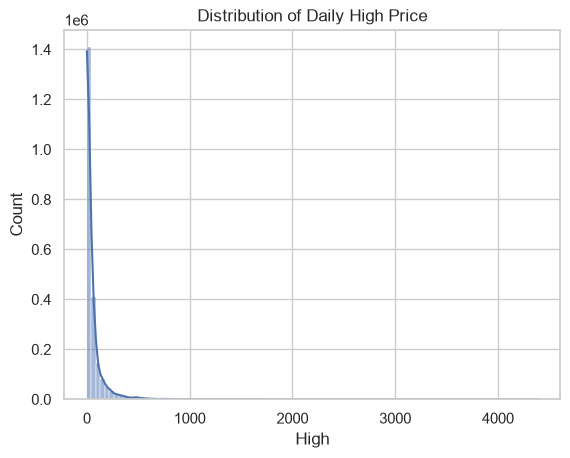

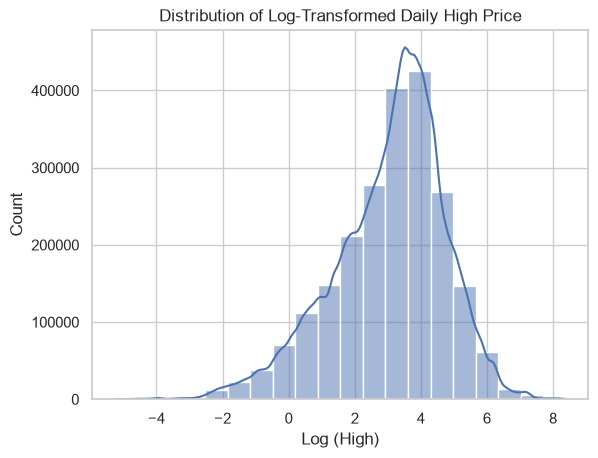

In [10]:
## Variable "High"
print("Variable 'High':")
print(data['High'].describe())
print(f"Skewness: {data['High'].skew()}")
print(f"Kurtosis: {data['High'].kurtosis()}")
print(f"Maximum: {data['High'].max()}, Minimum: {data['High'].min()}")
sns.histplot(data['High'], bins=100, kde=True)
plt.xlabel('High')
plt.title('Distribution of Daily High Price')
plt.show()
### Highest stock price reached during the trading session (USD).
### Clearly, this data is also heavily right-skewed, with a skewness of ~9.86 and kurtosis of ~177.63. The minimum high price is ~0.0052 USD, while the maximum high price is ~4388.10 USD. The median high price is ~27.87 USD, while the mean is ~63.02 USD. This indicates that there are some very high high prices that are pulling the mean up.
log_high = np.log(data['High'].dropna())
sns.histplot(log_high, bins=20, kde=True)
plt.xlabel('Log (High)')
plt.title('Distribution of Log-Transformed Daily High Price')
plt.show()

Variable 'Low':
count    2.219674e+06
mean     6.160433e+01
std      1.301917e+02
min      4.801000e-03
25%      7.583333e+00
50%      2.714500e+01
75%      6.431512e+01
max      4.316680e+03
Name: Low, dtype: float64
Skewness: 9.877614029552184
Kurtosis: 178.2942246953996
Maximum: 4316.68017578125, Minimum: 0.0048010000027716


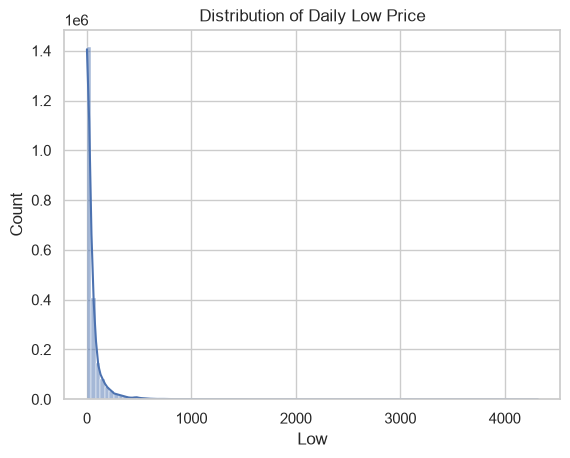

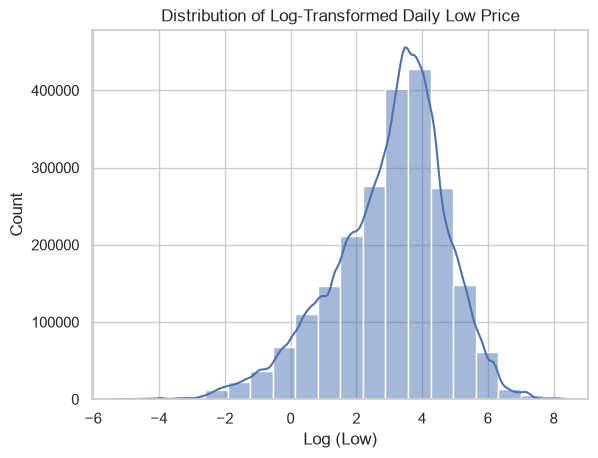

In [11]:
## Variable "Low"
print("Variable 'Low':")
print(data['Low'].describe())
print(f"Skewness: {data['Low'].skew()}")
print(f"Kurtosis: {data['Low'].kurtosis()}")
print(f"Maximum: {data['Low'].max()}, Minimum: {data['Low'].min()}")
sns.histplot(data['Low'], bins=100, kde=True)
plt.xlabel('Low')
plt.title('Distribution of Daily Low Price')
plt.show()
### Lowest stock price reached during the trading session (USD).
### Clearly, this data is also heavily right-skewed, with a skewness of ~9.87 and kurtosis of ~178.29. The minimum low price is ~0.0048 USD, while the maximum low price is ~4316.68 USD. The median low price is ~27.14 USD, while the mean is ~61.04 USD. This indicates that there are some very high low prices that are pulling the mean up.
log_low = np.log(data['Low'].dropna())
sns.histplot(log_low, bins=20, kde=True)
plt.xlabel('Log (Low)')
plt.title('Distribution of Log-Transformed Daily Low Price')
plt.show()

Variable 'Stock Splits':
count    2.219678e+06
mean     8.558764e-04
std      6.963233e-02
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      5.000000e+01
Name: Stock Splits, dtype: float64
Skewness: 399.72778661823463
Kurtosis: 255745.64045229493
Maximum: 50.0, Minimum: 0.0
Proportion of zero stock splits: 0.9996


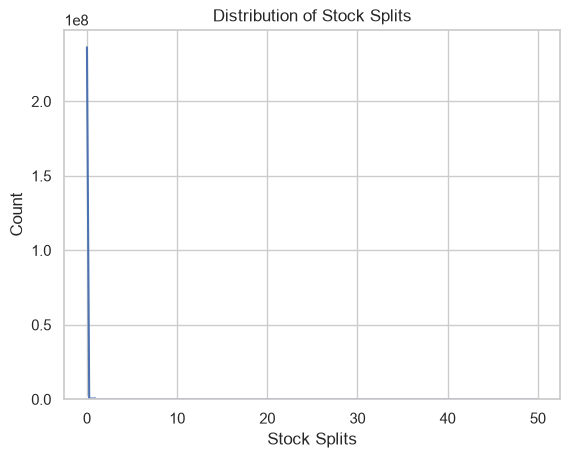

In [12]:
## Variable "Stock Splits"
print("Variable 'Stock Splits':")
print(data['Stock Splits'].describe())
print(f"Skewness: {data['Stock Splits'].skew()}")
print(f"Kurtosis: {data['Stock Splits'].kurtosis()}")
print(f"Maximum: {data['Stock Splits'].max()}, Minimum: {data['Stock Splits'].min()}")
print(
    f"Proportion of zero stock splits: "
    f"{(data['Stock Splits'] == 0).mean():.4f}"
)
### Stock split factor on the event date (default: `0.0` for regular trading days).
### ~99.9% of the stock split values are 0.0, indicating that most stocks do not have stock splits on most trading days. The maximum stock split value is 50.0, which is an outlier. The median stock split value is 0.0, while the mean is ~0.00085 USD. This indicates that there are some very high stock split values, which are outliers, that are pulling the mean up.

sns.histplot(data['Stock Splits'], bins=50, kde=True)
plt.xlabel('Stock Splits')
plt.title('Distribution of Stock Splits')
plt.show()

Variable 'Volume':
count    2.219678e+06
mean     1.088308e+07
std      5.624943e+07
min      0.000000e+00
25%      9.934000e+05
50%      2.582729e+06
75%      6.510700e+06
max      9.230856e+09
Name: Volume, dtype: float64
Skewness: 22.90134477415988
Kurtosis: 1136.2698094836162
Maximum: 9230856000, Minimum: 0


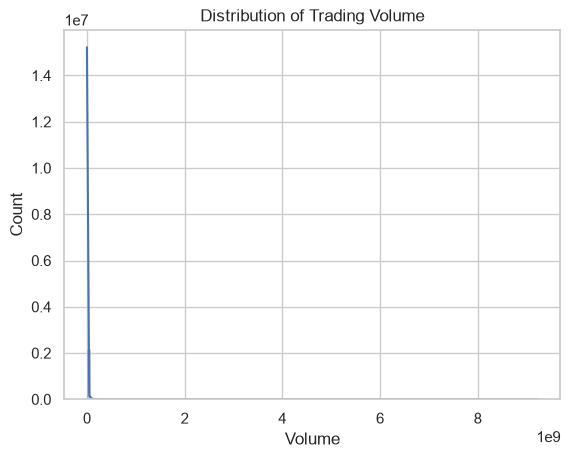

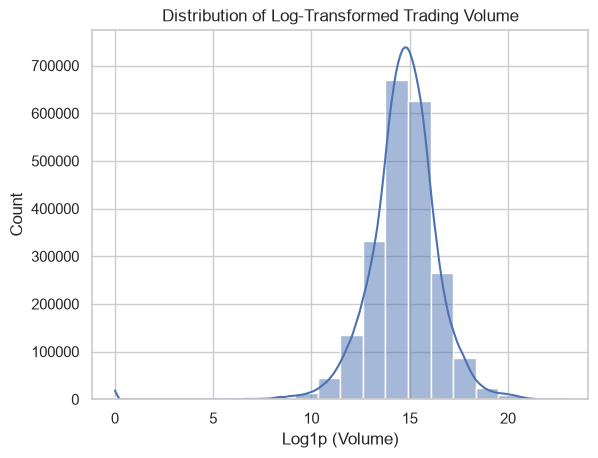

In [13]:
## Variable "Volume"
print("Variable 'Volume':")
print(data['Volume'].describe())
print(f"Skewness: {data['Volume'].skew()}")
print(f"Kurtosis: {data['Volume'].kurtosis()}")
print(f"Maximum: {data['Volume'].max()}, Minimum: {data['Volume'].min()}")
sns.histplot(data['Volume'], bins=100, kde=True)
plt.xlabel('Volume')
plt.title('Distribution of Trading Volume')
plt.show()
### Volume
### Clearly, this data is also heavily right-skewed, with a skewness of ~22.90 and kurtosis of ~1136.26. The minimum volume is 0.0, while the maximum volume is 9.23e+09. The median volume is ~2.58e+06, while the mean is ~1.088e+07. This indicates that there are some very high volumes that are pulling the mean up.
log_volume = np.log1p(data['Volume'].dropna())
sns.histplot(log_volume, bins=20, kde=True)
plt.xlabel('Log1p (Volume)')
plt.title('Distribution of Log-Transformed Trading Volume')
plt.show()

## **Multivariate Analysis**

/var/folders/q0/j86r80nn10v_z9zzcyz55gb00000gn/T/ipykernel_68006/3998560659.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_vars = data.select_dtypes(include=["object", "category"]).columns


Numeric: Index(['Adj Close', 'Close', 'Dividends', 'High', 'Low', 'Open',
       'Stock Splits', 'Volume'],
      dtype='str')
Categorical: Index(['Date', 'Ticker'], dtype='str')


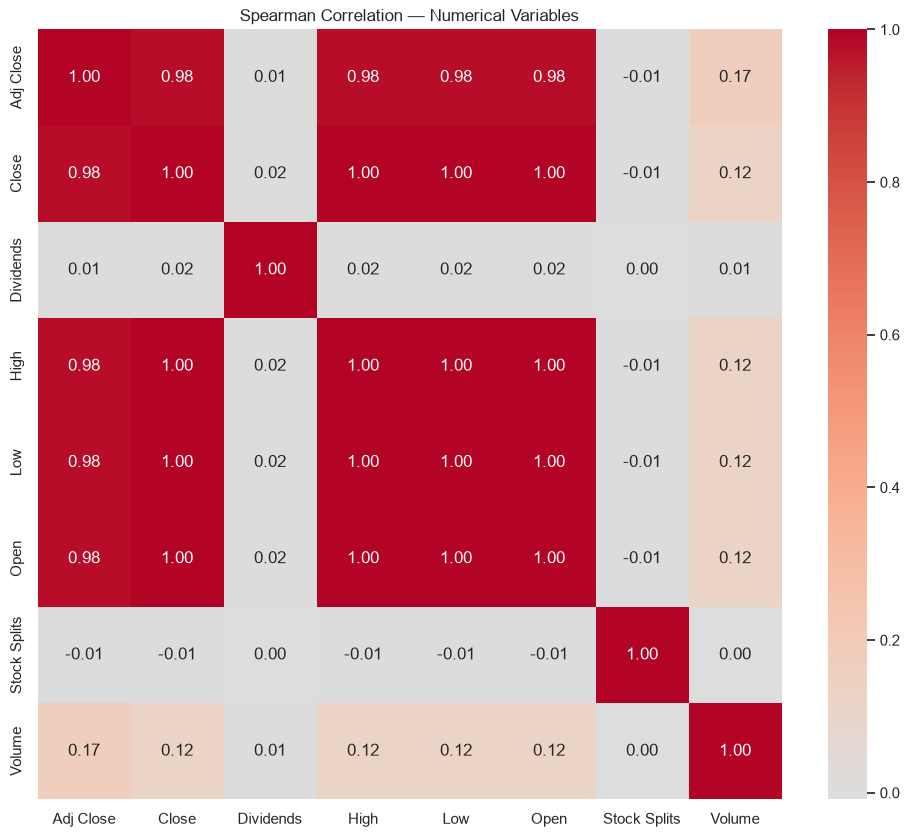

In [14]:
## Correlation Matrix for Numeric Variables

numeric_vars = data.select_dtypes(include="number").columns
categorical_vars = data.select_dtypes(include=["object", "category"]).columns
print("Numeric:", numeric_vars)
print("Categorical:", categorical_vars)

numeric_corr = (data[numeric_vars].corr(method="spearman"))
plt.figure(figsize=(12, 10))

sns.heatmap(numeric_corr,annot=True,fmt=".2f",cmap="coolwarm",center=0)
plt.title("Spearman Correlation — Numerical Variables")
plt.show()

### There is almost perfect correlation between Adj Close, Close, High, and Low. This is expected, as these variables are all related to the stock price. The Volume variable is not correlated with any of the other variables, which is also expected, as volume is a measure of how many shares are traded, and is not directly related to the stock price.
### In such a situation, it may be beneficial to drop some the highly correlated variables to reduce multicollinearity in any predictive modeling. For example, we can drop Close, High, and Low, and keep only Adj Close as the representative variable for stock price. We could also add further features to the dataset, such as moving averages, volatility measures, and other technical indicators, to capture more information about the stock price movements.

In [15]:
## Constructing Daily Returns

### Creating a variable to store daily returns of each stock gives us a better picture of performance of each stock over time. Daily returns are calculated as the percentage change in the adjusted closing price from one day to the next. This allows us to compare the performance of different stocks on a relative basis, regardless of their absolute price levels.
data = data.sort_values(["Ticker", "Date"])
data["Daily_Return"] = (data.groupby("Ticker")["Close"].pct_change(fill_method=None))
print(data["Daily_Return"].head())
### To note: For stocks that have been delisted, the calculated returns do not capture what happened to investors after that final price, i.e., does not record what they receive from bankruptcy liquidation or an acquisition.

## Constructing Intraday Returns

### This variable adds on to our analysis of price movements by capturing the percentage change in price from the opening price to the closing price of the same trading day. This allows us to analyze how much a stock's price fluctuates within a single trading session, which can be useful for understanding market volatility and investor sentiment.
data["Intraday_Return"] = (data["Close"] - data["Open"])/data["Open"]
print(data["Intraday_Return"].head())

## Constructing Absolute Returns

### This variable represents the absolute value of the daily returns, which can be useful for analyzing the magnitude of price movements without considering the direction.
data["Abs_Return"] = data["Daily_Return"].abs()
print(data["Abs_Return"].head())

## Constructing Daily Range

### This variable captures the difference between the highest and lowest prices of a stock during a trading day, which can be useful for analyzing market volatility and investor sentiment.
data["Daily_Range"] = (data["High"] - data["Low"])/data["Open"]
print(data["Daily_Range"].head())

## Constructing Rolling Volatility

### This measures how variable the stock's returns have recently been, which can be useful for analyzing market volatility and investor sentiment. A higher volatility indicates that the stock's price has been fluctuating more, while a lower volatility indicates that the stock's price has been relatively stable.
data["Volatility"] = data.groupby("Ticker")["Daily_Return"].transform(lambda x: x.shift(1).rolling(20).std())
print(data["Volatility"].head())

## Constructing Overnight Gap

### This variable captures the difference between the opening price and the previous day's closing price, which can be useful for analyzing the impact of news or events on stock prices.
data["Prev_Close"] = data.groupby("Ticker")["Close"].shift(1)
data["Gap"] = (data["Open"] - data["Prev_Close"])/data["Prev_Close"]
print(data["Gap"].head(30))

0         NaN
1   -0.082386
2    0.089783
3   -0.090909
4    0.026563
Name: Daily_Return, dtype: float64
0   -0.032967
1   -0.059680
2    0.065053
3   -0.058824
4    0.023364
Name: Intraday_Return, dtype: float64
0         NaN
1    0.082386
2    0.089783
3    0.090909
4    0.026563
Name: Abs_Return, dtype: float64
0    0.219780
1    0.074236
2    0.095310
3    0.085294
4    0.048287
Name: Daily_Range, dtype: float64
0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
Name: Volatility, dtype: float64
0          NaN
1    -0.024148
2     0.023220
3    -0.034091
4     0.003125
5    -0.004566
6    -0.004552
7    -0.002967
8     0.000000
9     0.018923
10    0.018414
11    0.016854
12    0.000000
13    0.000000
14    0.001383
15   -0.002728
16    0.016760
17   -0.002747
18   -0.023256
19    0.007496
20   -0.018518
21    0.006803
22   -0.004000
23    0.000000
24   -0.001314
25    0.003769
26    0.027219
27    0.024390
28    0.055556
29    0.003155
Name: Gap, dtype: float64


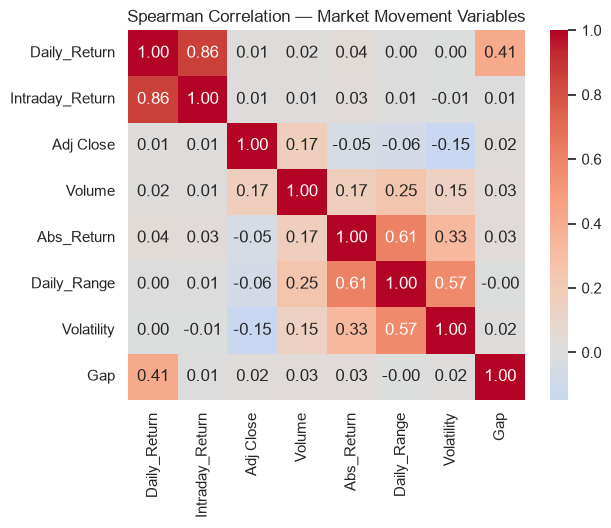

In [16]:
## New correlation matrix with new variables
analysis_cols = ["Daily_Return", "Intraday_Return", "Adj Close", "Volume", "Abs_Return", "Daily_Range", "Volatility", "Gap"]

corr = data[analysis_cols].corr(method="spearman")

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Spearman Correlation — Market Movement Variables")
plt.show()

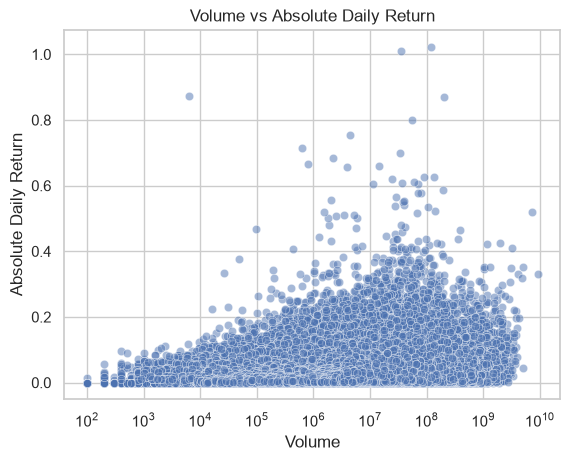

In [17]:
## Comparing Volume and Absolute Returns
### Are higher trading volumes associated with larger daily price movements?

sns.scatterplot(data=data, x="Volume", y="Abs_Return", alpha=0.5)
plt.xscale("log")
plt.xlabel("Volume")
plt.ylabel("Absolute Daily Return")
plt.title("Volume vs Absolute Daily Return")
plt.show()

### At low trading volumes, very large absolute returns appear relatively uncommon. As volume increases, the range of possible absolute returns becomes wider. This is consistent with the low positive correlation as seen in the heatmap.

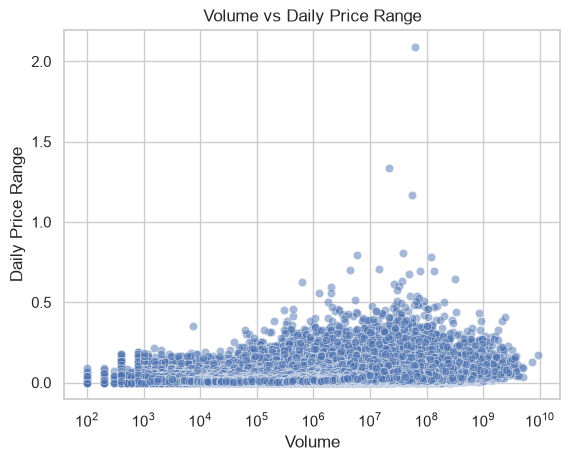

In [18]:
## Comparing Volume and Daily Range
### Are higher trading volumes associated with larger intraday price ranges?

sns.scatterplot(data=data, x="Volume", y="Daily_Range", alpha=0.5)
plt.xscale("log")
plt.xlabel("Volume")
plt.ylabel("Daily Price Range")
plt.title("Volume vs Daily Price Range")
plt.show()

### Trading volume exhibits a weak positive association with daily price range. Higher-volume observations tend to exhibit a broader range of intraday price movements, although the relationship is highly dispersed.

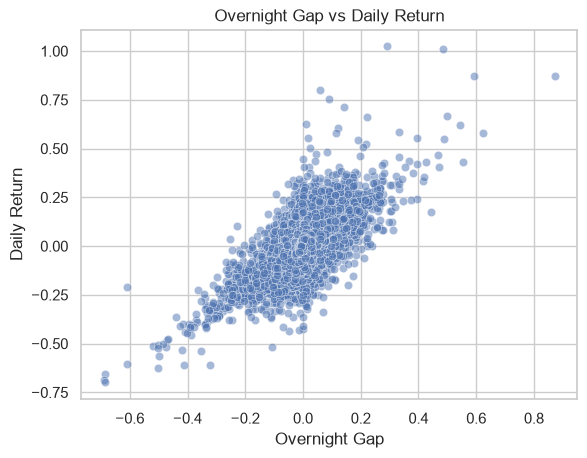

In [19]:
## Comparing Gap and Daily Returns
### Are larger overnight gaps associated with larger intraday price movements?
sns.scatterplot(data=data, x="Gap", y="Daily_Return", alpha=0.5)
plt.xlabel("Overnight Gap")
plt.ylabel("Daily Return")
plt.title("Overnight Gap vs Daily Return")
plt.show()

### Overnight gaps show a moderate positive association with daily returns. This relationship is partly mechanical, as the overnight movement from the previous close to the current open forms part of the overall close-to-close daily return. In contrast, the near-zero association between overnight gaps and intraday returns suggests that the magnitude and direction of overnight movements are not strongly associated with subsequent open-to-close movements of stock prices.

Since we now have pooled relationships, we can try identifying the above three relationships for individual stocks.

In [20]:
## Stockwise Correlation between Volume and Absolute Returns
individual_volume_absreturn=data.groupby('Ticker').apply(lambda x: x['Volume'].corr(x['Abs_Return'], method='spearman'), include_groups=False)
print(individual_volume_absreturn.head())
print((individual_volume_absreturn.describe()))
print((individual_volume_absreturn>0).value_counts())

## Stockwise correlation between Volume and Daily Range
individual_volume_dailyrange = data.groupby("Ticker").apply(lambda x: x["Volume"].corr(x["Daily_Range"], method="spearman"),include_groups=False)
print(individual_volume_dailyrange.head())
print(individual_volume_dailyrange.describe())
print((individual_volume_dailyrange>0).value_counts())

## Stockwise correlation between Gap and Daily Returns
individual_gap_dailyreturn = data.groupby("Ticker").apply(lambda x: x["Gap"].corr(x["Daily_Return"], method="spearman"),include_groups=False)
print(individual_gap_dailyreturn.head())
print(individual_gap_dailyreturn.describe())
print((individual_gap_dailyreturn > 0).value_counts())

### All stocks show a positive correlation in all three relationships.

Ticker
A       0.288331
AAPL    0.269398
ABBV    0.397765
ABT     0.175369
ACN     0.284188
dtype: float64
count    233.000000
mean       0.235587
std        0.109562
min        0.006229
25%        0.164336
50%        0.221271
75%        0.304135
max        1.000000
dtype: float64
True    233
Name: count, dtype: int64
Ticker
A       0.414056
AAPL    0.462011
ABBV    0.508931
ABT     0.228397
ACN     0.411519
dtype: float64
count    233.000000
mean       0.332435
std        0.161172
min       -0.167956
25%        0.236731
50%        0.326710
75%        0.441212
max        1.000000
dtype: float64
True     227
False      6
Name: count, dtype: int64
Ticker
A       0.452305
AAPL    0.428643
ABBV    0.395190
ABT     0.389103
ACN     0.441475
dtype: float64
count    233.000000
mean       0.418246
std        0.059674
min        0.295209
25%        0.386183
50%        0.417853
75%        0.450084
max        1.000000
dtype: float64
True    233
Name: count, dtype: int64


## **Temporal Analysis**

Now we need to understand whether past information has a relationship with subsequent behaviour. We'll limit this analysis to a lag of one day.

0.0007395359587063287


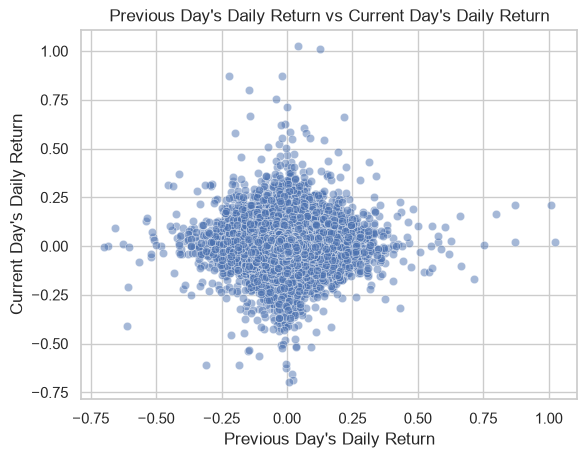

/Users/aaravkumar/Desktop/ai and ml/env/lib/python3.14/site-packages/pandas/core/nanops.py:1673: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


Ticker
A      -0.013088
AAPL    0.015552
ABBV    0.007214
ABT     0.000915
ACN    -0.025804
dtype: float64
count    232.000000
mean      -0.004466
std        0.029129
min       -0.216353
25%       -0.020569
50%       -0.003642
75%        0.013597
max        0.067286
dtype: float64
0.1923315263336953


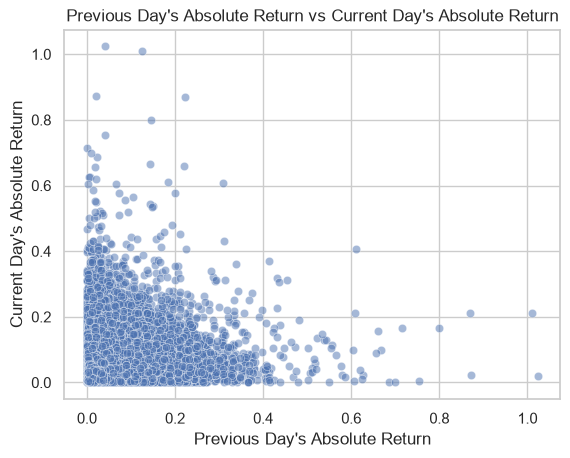

Ticker
A       0.196412
AAPL    0.177571
ABBV    0.107662
ABT     0.127724
ACN     0.160914
dtype: float64
count    232.000000
mean       0.155137
std        0.038510
min       -0.005387
25%        0.130394
50%        0.150669
75%        0.176651
max        0.317282
dtype: float64


/Users/aaravkumar/Desktop/ai and ml/env/lib/python3.14/site-packages/pandas/core/nanops.py:1673: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


In [21]:
## Temporal Analysis: Lagged Daily Returns

data['Return_lag_1']=data.groupby('Ticker')['Daily_Return'].shift(1)
print((data['Daily_Return'].corr(data['Return_lag_1'], method='spearman')))
sns.scatterplot(data=data, x="Return_lag_1", y="Daily_Return", alpha=0.5)
plt.xlabel("Previous Day's Daily Return")
plt.ylabel("Current Day's Daily Return")
plt.title("Previous Day's Daily Return vs Current Day's Daily Return")
plt.show()

### Clearly, the daily returns of the past trading day have a near-zero correlation with the current day's daily returns. This suggests that the daily returns of a stock are not strongly influenced by the previous day's returns, and that other factors, such as market news or events, may have a greater impact on daily returns.
### We can extend the analysis to a stockwise level.
individual_lagged_dailyreturn = data.groupby("Ticker").apply(lambda x: x["Daily_Return"].corr(x["Return_lag_1"], method="spearman"),include_groups=False)
print(individual_lagged_dailyreturn.head())
print(individual_lagged_dailyreturn.describe())
### The analysis holds at the stockwise level as well.

## Temporal Analysis: Lagged Absolute Returns

data["Abs_Return_lag_1"] = (data.groupby("Ticker")["Abs_Return"].shift(1))
print(data["Abs_Return"].corr(data["Abs_Return_lag_1"], method="spearman"))
sns.scatterplot(
    data=data,
    x="Abs_Return_lag_1",
    y="Abs_Return",
    alpha=0.5
)
plt.xlabel("Previous Day's Absolute Return")
plt.ylabel("Current Day's Absolute Return")
plt.title("Previous Day's Absolute Return vs Current Day's Absolute Return")
plt.show()

## Stockwise correlation

individual_lagged_abs_return = data.groupby("Ticker").apply(
    lambda x: x["Abs_Return"].corr(
        x["Abs_Return_lag_1"],
        method="spearman"
    ),
    include_groups=False
)
print(individual_lagged_abs_return.head())
print(individual_lagged_abs_return.describe())

## EDA Conclusions

The exploratory analysis revealed several important characteristics of the stock-market dataset that should inform subsequent machine-learning decisions.

### Feature Redundancy

The raw price variables (`Open`, `High`, `Low`, `Close`, and `Adj Close`) were found to be extremely highly correlated, with Spearman correlations close to 1 for several pairs. This is expected because these variables measure different aspects of the same daily stock price.

Using all raw price variables as independent predictors may introduce substantial redundancy. The analysis therefore constructed additional variables describing movements, including `Daily_Return`, `Intraday_Return`, `Abs_Return`, `Daily_Range`, `Gap`, and rolling `Volatility`.

### Trading Volume and Price Movements

Trading volume exhibited almost no monotonic association with the **direction of daily returns**, with a Spearman correlation of approximately 0.02 between `Volume` and `Daily_Return`.

However, stronger positive associations were observed between:

* `Volume` and `Abs_Return` (approximately **0.17**)
* `Volume` and `Daily_Range` (approximately **0.25**)

The corresponding scatterplots showed substantial dispersion but were consistent with these weak positive associations. This suggests that higher trading activity is more closely associated with the **magnitude of price movement** than with whether prices increase or decrease.

### Volatility and Price-Movement Magnitude

Historical rolling volatility showed meaningful positive associations with subsequent measures of price movement. In particular, the analysis found correlations of approximately:

* `Volatility` and `Abs_Return`: **0.33**
* `Volatility` and `Daily_Range`: **0.57**

Since rolling volatility was constructed from the preceding 20 return observations using `shift(1)`, the measure excludes the current day's return. The results therefore suggest that periods of elevated recent volatility tend to be associated with larger subsequent daily price movements and wider intraday trading ranges.

### Overnight Gaps

The overnight percentage gap showed a moderate positive association with `Daily_Return`, with a Spearman correlation of approximately **0.41**.

This relationship should be interpreted cautiously because the overnight gap forms part of the overall close-to-close daily price movement. The relationship is therefore partly mechanical.

In contrast, the correlation between `Gap` and `Intraday_Return` was approximately zero. Thus, while overnight movements contribute to the overall daily return, the pooled data provide little evidence of a monotonic relationship between the direction or magnitude of an overnight gap and the stock's subsequent open-to-close movement.

### Temporal Dependence

The analysis compared each stock's current daily return with its previous trading day's return. The resulting Spearman correlation was approximately **0.001**, indicating virtually no monotonic association between consecutive daily returns in the pooled dataset.

This suggests that the immediately preceding day's return, considered in isolation, contains little information about the direction or magnitude of the subsequent day's return. However, this result does not imply that stock returns are entirely unpredictable, as nonlinear relationships, interactions with other variables, longer-term patterns, and stock-specific relationships are not captured by this single correlation.

### Cross-Stock Differences

Because the dataset contains observations from many different stocks with different trading histories, liquidity levels, volatility characteristics, and price behaviour, pooled relationships should not automatically be assumed to hold equally for every stock.

The cross-stock analysis therefore provides an important complement to the pooled analysis by examining relationships within individual tickers. Differences between pooled and stock-specific correlations indicate that heterogeneity between companies should be considered when constructing and evaluating predictive models.

---

# Implications for Machine Learning

The EDA provides several direct lessons for the design of a subsequent machine-learning pipeline.

### 1. Engineered features may be more informative than raw prices

Rather than relying primarily on highly correlated raw OHLC price levels, subsequent models should consider features describing market behaviour. Additional features based entirely on historical information could also be explored, such as lagged returns, rolling average volume, and relative volume.

The objective is not necessarily to remove all raw price variables, but to avoid treating several nearly redundant price measures as though they provide completely independent information.

### 2. Multicollinearity and redundant features should be considered

The extremely strong correlations among `Open`, `High`, `Low`, and `Close` may be problematic for models sensitive to multicollinearity, particularly linear models.

Feature selection, dimensionality reduction, or choosing representative/engineered features may therefore be appropriate.

Tree-based models are generally less affected by multicollinearity in the same way as linear regression, although redundant predictors can still add unnecessary complexity.

### 3. Feature scaling and transformation depend on the model

Several variables, particularly `Volume`, are heavily right-skewed and span very large ranges.

Potential transformations include log volume or relative volume. Relative volume may be particularly useful because raw trading volumes are difficult to compare directly across stocks of very different sizes and liquidity levels.

Transformations should nevertheless be selected based on the intended model rather than applied solely to make distributions appear more symmetric.

### 4. Temporal leakage must be prevented

Because the observations are time ordered, feature engineering must ensure that predictors contain only information that would have been available at the point when a prediction was made.

For example, the rolling volatility variable was constructed as:

```python
data["Volatility_20D"] = (
    data.groupby("Ticker")["Daily_Return"]
        .transform(
            lambda x: x.shift(1).rolling(20).std()
        )
)
```

The `shift(1)` ensures that today's return is not included in a variable intended to describe volatility known before the current observation.

The same principle should be applied to all rolling and lagged features.

### 5. Train/test splitting should preserve chronological order

A conventional random train/test split would generally be inappropriate for a forecasting application because observations from the future could enter the training set while earlier observations enter the test set.

Instead, the data should be separated chronologically:

```text
PAST                                      FUTURE
─────────────────────────────────────────────────>

       Training period       │      Test period
                             │
─────────────────────────────┼────────────────────
```

This better represents the actual forecasting problem:

> Train the model using historical information and evaluate it on genuinely later observations.

More sophisticated validation could subsequently use expanding-window or rolling-window approaches.

### 6. Cross-stock heterogeneity should be incorporated

Different stocks have different typical:

* trading volumes;
* volatility;
* liquidity;
* price ranges;
* listing histories.

Consequently, raw values may not always be directly comparable across companies.

Stock-relative features such as `Relative_Volume` and rolling volatility can help describe an observation relative to the stock's **own recent history**.

The eventual modelling strategy should also consider whether the objective is to build:

> **one pooled model across all stocks**

or

> **stock-specific models**

because the EDA indicates that relationships observed at the aggregate level may not necessarily apply uniformly across individual companies.

### 7. Missing values from engineered features are meaningful

Some missing observations arise naturally from feature construction.

For example:

```python
.shift(1)
```

produces a missing value for the first observation of each stock, while:

```python
.shift(1).rolling(20)
```

requires sufficient historical observations before a 20-period feature can be calculated.

This is particularly relevant for recently listed stocks.

Such missingness should therefore not automatically be interpreted as a data-quality error or filled without considering its origin.

### 8. Corporate actions and delisted stocks require care

Returns based on adjusted closing prices help account for certain corporate actions, but the treatment of dividends, splits, acquisitions, and delistings depends on the underlying data source.

In particular, the final observed return of a delisted stock may not capture the complete economic return ultimately received by shareholders.

These limitations should be documented when interpreting both model inputs and model performance.

---

## Overall ML Takeaway

The EDA suggests that the modelling problem should focus less on **absolute stock price levels** and more on **relative market behaviour over time**.

The strongest candidate feature families emerging from the analysis are therefore:

$$
\boxed{
\text{Returns}
+
\text{Trading Activity}
+
\text{Intraday Movement}
+
\text{Historical Volatility}
+
\text{Lagged/Rolling Information}
}
$$
